In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "15_jun_logs.csv",
    engine="python",
    on_bad_lines="skip"
)

In [3]:
df['metadata_date'] = pd.to_datetime(df['metadata_date'])

In [4]:
df['hour'] = df['metadata_date'].dt.hour
df['minute'] = df['metadata_date'].dt.minute

In [5]:
df[['metadata_date','hour','minute']].head()

,metadata_date,hour,minute
0,2026-06-15 16:03:29.488,16,3
1,2026-06-15 16:03:29.635,16,3
2,2026-06-15 16:03:30.037,16,3
3,2026-06-15 16:03:30.377,16,3
4,2026-06-15 16:03:30.787,16,3


In [6]:
features = [
    'hour',
    'minute',
    'bat_current',
    'bat_volt',
    'load_current',
    'load_volt'
]

X = df[features]

y = df['pv_current']

In [7]:
X = X.fillna(0)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
y_pred = model.predict(X_test)

In [11]:
print("MAE :", mean_absolute_error(y_test, y_pred))

print("RMSE :",
      np.sqrt(mean_squared_error(y_test, y_pred)))

print("R2 Score :",
      r2_score(y_test, y_pred))

MAE : 0.0031839089089089213
RMSE : 0.01740891901568357
R2 Score : 0.9926500241513903


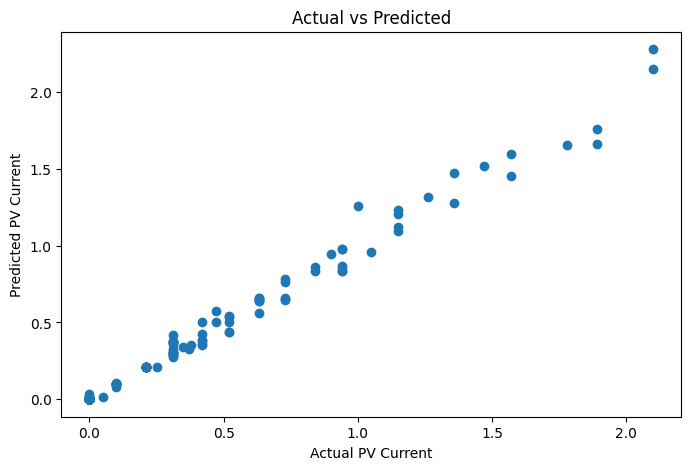

In [12]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual PV Current")
plt.ylabel("Predicted PV Current")

plt.title("Actual vs Predicted")

plt.show()

## Model Performance

1. The Random Forest model achieved a low prediction error.

2. MAE and RMSE values indicate that the predicted solar current values are close to the actual values.

3. The model achieved an R² score of 0.99, showing a strong relationship between the selected features and solar current.

4. The model serves as a baseline forecasting solution and can be improved further using larger historical datasets.

In [14]:
import joblib

joblib.dump(model, "solar_forecasting_model.pkl")

print("Model saved successfully")

Model saved successfully


In [15]:
import joblib

model = joblib.load("solar_forecasting_model.pkl")

print("Model loaded successfully")

Model loaded successfully
